In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint
from scipy.stats import chi2_contingency, fisher_exact, ttest_ind, ttest_rel, pointbiserialr, pearsonr
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML
from pathlib import Path

import os
import sys
import src.analysis_utility_funcs as unified_funcs # ---- this worked because of the new pyproject.toml file, and we ran 'pip install -e .' in the conda env setup script, which runs the pyproject.toml, which basically makes any (root-level) cross-folder imports work without needing to mess with sys.path. So I can import python scripts if I want from src, run_annotation, archive, whichever.

## The complete annotated Franken dataset in a dataframe:
- ### TWO intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- ### Within each, EIGHT causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- ### Each causal condition contains TEN annotated scenarios, SID goes from 0-9 within each.
- ### Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- ### Each scenario generates multiple (5-10) events, each event gets its own row. So total row count is 800+.

In [2]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../../annotated_outputs/franken_o1o2/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]
display(HTML(all_FRANKEN_df[0:5].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-55'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-68'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'i': '0', 'residents of the community who use or value the park': '-35'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'i': '-12', 'residents of the community who use or value the park': '-55'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'i': '12', 'residents of the community who use or value the park': '84'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in all_FRANKEN_df: 754


## Split the dataframe into two, one for mild only and one for severe only.
#### Each dataframe still has eight causal conditions, each having 10 scenarios, 80 total.

In [3]:
mild_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["intensity"] == "mild_harm_mild_good"]
severe_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["intensity"] == "severe_harm_very_good"]
print("mild_FRANKEN_df preview:")
display(HTML(mild_FRANKEN_df[0:2].to_html()))
print("number of rows in mild_FRANKEN_df:", len(mild_FRANKEN_df))
print("severe_FRANKEN_df preview:")
display(HTML(severe_FRANKEN_df[0:2].to_html()))
print("number of rows in severe_FRANKEN_df:", len(severe_FRANKEN_df))

mild_FRANKEN_df preview:


,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-55'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-68'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in mild_FRANKEN_df: 309
severe_FRANKEN_df preview:


,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
380,0,1: initiate the major urban renewal project.,Historical buildings are demolished,i,+,+,+,"{'residents of the long-established residential community': '-72', 'i': '0'}",3.0,severe_harm_very_good,cc_evitable_action_yes_stories
381,0,1: initiate the major urban renewal project.,Residents are relocated from the long-established community,i,+,+,+,"{'residents of the long-established residential community': '-88', 'i': '-72'}",3.0,severe_harm_very_good,cc_evitable_action_yes_stories


number of rows in severe_FRANKEN_df: 445


## Shared helpers

- `sig_stars` -- turns a p-value into significance stars.
- `bar_dot_sem` -- bar (mean) + SEM error bars + jittered individual points, for unpaired group comparisons.
- `paired_bar_dot_sem` -- same, but for paired/matched data: draws a thin connecting line between each matched pair of points (e.g. the same scenario's CC vs COC value).
- `per_scenario_proportion` -- collapses an event-level +/- column down to one proportion per scenario (per SID), so that scenario -- not event -- is the unit of analysis.

In [4]:
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def bar_dot_sem(ax, groups, colors=None):
    """groups: dict label -> array-like of numeric values. Draws bar (mean) + SEM error bars + jittered individual points."""
    labels = list(groups.keys())
    if colors is None:
        colors = ["cornflowerblue", "indianred"][:len(labels)]
    means = [np.mean(groups[l]) for l in labels]
    sems  = [np.std(groups[l], ddof=1) / np.sqrt(len(groups[l])) for l in labels]
    ns    = [len(groups[l]) for l in labels]

    x = np.arange(len(labels))
    ax.bar(x, means, yerr=sems, capsize=6, color=colors, error_kw=dict(elinewidth=1.5), zorder=2)

    rng = np.random.default_rng(0)
    for xi, l in zip(x, labels):
        vals = np.asarray(groups[l], dtype=float)
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(xi + jitter, vals, color="black", alpha=0.4, s=14, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{l}\n(n={n})" for l, n in zip(labels, ns)])
    return means, sems, ns

def paired_bar_dot_sem(ax, vals_a, vals_b, label_a="A", label_b="B", colors=None):
    """vals_a, vals_b: aligned arrays (same length, same order = same underlying scenario).
    Draws bar (mean) + SEM error bars per group, jittered dots, and a line connecting each matched pair."""
    vals_a = np.asarray(vals_a, dtype=float)
    vals_b = np.asarray(vals_b, dtype=float)
    n = len(vals_a)
    if colors is None:
        colors = ["pink", "turquoise"]

    means = [vals_a.mean(), vals_b.mean()]
    sems  = [vals_a.std(ddof=1) / np.sqrt(n), vals_b.std(ddof=1) / np.sqrt(n)]

    x = np.array([0, 1])
    ax.bar(x, means, yerr=sems, capsize=6, color=colors, error_kw=dict(elinewidth=1.5), zorder=2)

    rng = np.random.default_rng(0)
    jitter = rng.uniform(-0.15, 0.15, size=n)
    for i in range(n):
        ax.plot([jitter[i], 1 + jitter[i]], [vals_a[i], vals_b[i]], color="gray", alpha=0.3, lw=0.8, zorder=1)
    ax.scatter(jitter, vals_a, color="black", alpha=0.5, s=14, zorder=3)
    ax.scatter(1 + jitter, vals_b, color="black", alpha=0.5, s=14, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{label_a}\n(n={n})", f"{label_b}\n(n={n})"])
    return means, sems, n

def per_scenario_proportion(df, causal_condition, column):
    """Returns a Series indexed by SID: proportion of '+' events for this causal_condition (one value per scenario)."""
    sub = df[df["causal_condition"] == causal_condition]
    return sub.groupby("SID")[column].apply(lambda s: (s == "+").mean())

# Analysis 0 -- Is there any kind of correlation between C/I/K labels across all scenarios?

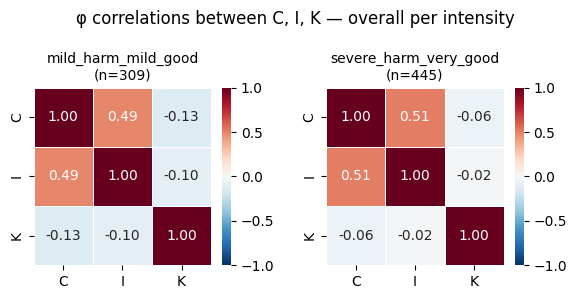

In [5]:
def plot_label_coherence_overall(df):
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    for ax, intensity in zip(axs, ["mild_harm_mild_good", "severe_harm_very_good"]):
        intensity_df = df[df["intensity"] == intensity]
        encoded = intensity_df[["C", "I", "K"]].replace({"+": 1, "-": 0})
        phi = encoded.corr()
        n = len(intensity_df)

        sns.heatmap(phi, annot=True, fmt=".2f", vmin=-1, vmax=1,
                    center=0, cmap="RdBu_r", ax=ax, square=False,
                    linewidths=0.5)
        ax.set_title(f"{intensity}\n(n={n})", fontsize=10)

    plt.suptitle("φ correlations between C, I, K — overall per intensity", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_label_coherence_overall(all_FRANKEN_df)

# Analysis 1 -- Do "means-harm" scenarios generate more intentional events than "side-effect-harm" scenarios?

## Analysis 1A -- Comparing the *within-scenario* proportion of "I+" events between CC (means) and COC (side-effect) counterparts of scenarios
### **Commonsense hypothesis =** Events coming out of scenarios where the action is a direct means to a harm (CC) should feel more intentional than the events coming out of side-effects-harm (COC) scenarios, so **more of the generated events should be I+ for CC scenarios.**

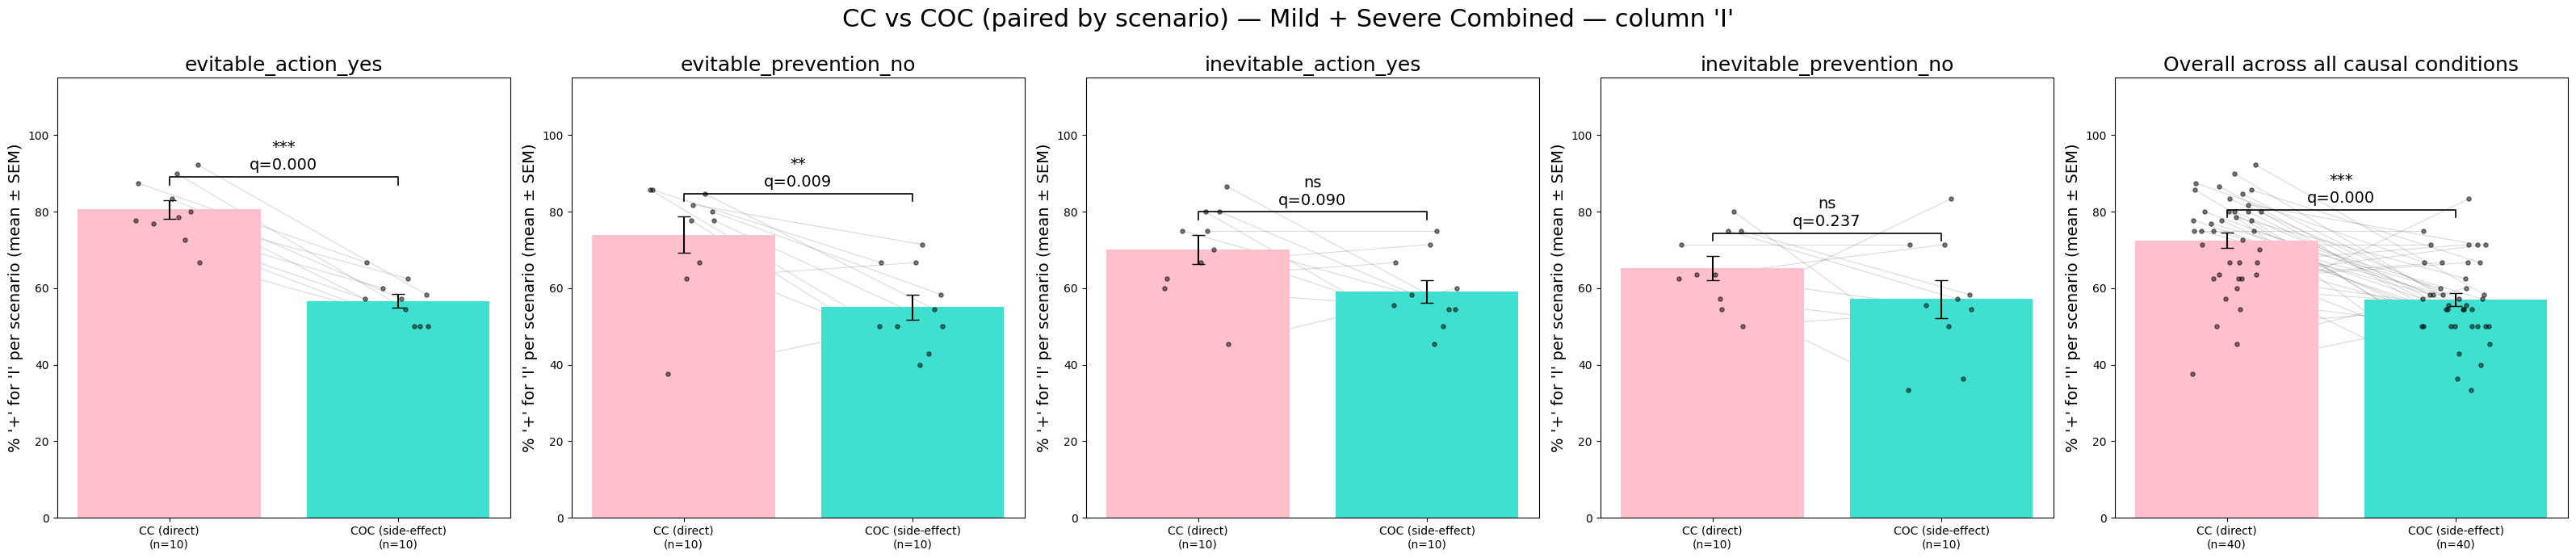

In [39]:
def paired_proportion_barplots(df, title_suffix, column, condition_pairs, pair_labels, colors, suptitle):
    """condition_pairs: list of (cond_a, cond_b, panel_title). pair_labels: (label_a, label_b).
    Computes per-scenario proportion of '+' in `column`, pairs cond_a vs cond_b by SID within each
    condition-pair, paired-t-tests each pair plus an overall pooled paired test, and BH-FDR corrects
    across the resulting p-values."""
    label_a, label_b = pair_labels
    fig, axs = plt.subplots(1, 5, figsize=(32, 7))

    panel_vals = []
    all_vals_a, all_vals_b = [], []
    for cond_a, cond_b, panel_title in condition_pairs:
        prop_a = per_scenario_proportion(df, cond_a, column)
        prop_b = per_scenario_proportion(df, cond_b, column)
        common_sids = sorted(set(prop_a.index) & set(prop_b.index))
        vals_a = prop_a.loc[common_sids].values * 100
        vals_b = prop_b.loc[common_sids].values * 100
        panel_vals.append((vals_a, vals_b, panel_title))
        all_vals_a.extend(vals_a)
        all_vals_b.extend(vals_b)
    panel_vals.append((np.array(all_vals_a), np.array(all_vals_b), "Overall across all causal conditions"))

    p_vals = [ttest_rel(va, vb).pvalue for va, vb, _ in panel_vals]
    _, p_adj, _, _ = multipletests(p_vals, method="fdr_bh")

    for ax, (vals_a, vals_b, panel_title), q_val in zip(axs, panel_vals, p_adj):
        means, sems, n = paired_bar_dot_sem(ax, vals_a, vals_b, label_a, label_b, colors=colors)
        y_top = max(m + s for m, s in zip(means, sems)) + 4
        ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
        ax.text(0.5, y_top + 3, f"{sig_stars(q_val)}\nq={q_val:.3f}", ha="center", va="bottom", fontsize=14)
        ax.set_ylim(0, 115)
        ax.set_ylabel(f"% '+' for '{column}' per scenario (mean ± SEM)")
        ax.yaxis.label.set_size(14)
        ax.set_title(panel_title, fontsize=18)

    plt.suptitle(suptitle, fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

condition_pairs_cc_coc = [
    ("cc_evitable_action_yes_stories",    "coc_evitable_action_yes_stories",    "evitable_action_yes"),
    ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories", "evitable_prevention_no"),
    ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories",  "inevitable_action_yes"),
    ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories","inevitable_prevention_no"),
]

# paired_proportion_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="I",
#                             condition_pairs=condition_pairs_cc_coc, pair_labels=("CC", "COC"),
#                             colors=["pink", "turquoise"],
#                             suptitle="CC vs COC (paired by scenario) — Mild Harm/Mild Good — column 'I'")
# paired_proportion_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="I",
#                             condition_pairs=condition_pairs_cc_coc, pair_labels=("CC", "COC"),
#                             colors=["pink", "turquoise"],
#                             suptitle="CC vs COC (paired by scenario) — Severe Harm/Very Good — column 'I'")
paired_proportion_barplots(all_FRANKEN_df, "Mild + Severe Combined", column="I",
                            condition_pairs=condition_pairs_cc_coc, pair_labels=("CC (direct)", "COC (side-effect)"),
                            colors=["pink", "turquoise"],
                            suptitle="CC vs COC (paired by scenario) — Mild + Severe Combined — column 'I'")

### **RESULT:** Hypothesis is true -- CC (mean-sharm) scenarios generate more I+ (intentional) events compared to COC.

## Analysis 1B -- Do "means-harm" scenarios generally assign I+ to primary-harm events more frequently compared to "side-effect" scenarios?

### Only use the PRIMARY HARM EVENT'S "I" label for a scenario and look at proportion of I+ for the picked event *across* scenarios

### **Hypothesis:** The CC group of scenarios should have more scenarios where the primary harm event is labelled I+ compared to COC

n pairs = 40
CC  primary harm I+: 13/40  (32.5%)
COC primary harm I+: 1/40  (2.5%)
McNemar (Fisher but paired-binary) exact test: statistic=1.0, p=0.0018  **


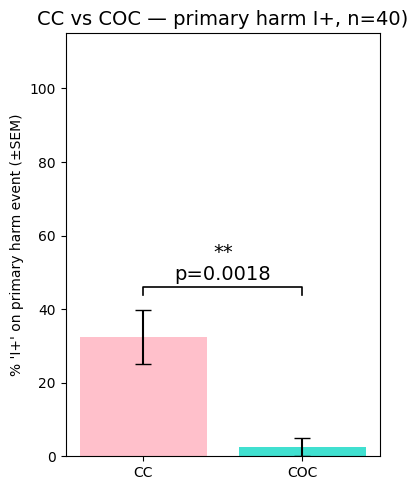

In [7]:
### Analysis 1B -- I+/- on primary harm event: CC vs COC (McNemar's paired exact test)

primary_harm_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv")

def causal_condition_to_structure_evit_action(cc):
    structure    = "cc" if cc.startswith("cc") else "coc"
    evitability  = "inevitable" if "inevitable" in cc else "evitable"   # NOTE: check "inevitable" first, it's a substring of "evitable"'s complement here so order matters
    action       = "action_yes" if "action_yes" in cc else "prevention_no"
    return pd.Series({"structure": structure, "evitability": evitability, "action": action})

primary_harm_df = primary_harm_df.join(primary_harm_df["causal_condition"].apply(causal_condition_to_structure_evit_action))
primary_harm_df["I_binary"] = primary_harm_df["I"].map({"+": 1, "-": 0})

cc_primary  = primary_harm_df[primary_harm_df["structure"] == "cc"][["SID", "evitability", "action", "I_binary"]].rename(columns={"I_binary": "cc_I"})
coc_primary = primary_harm_df[primary_harm_df["structure"] == "coc"][["SID", "evitability", "action", "I_binary"]].rename(columns={"I_binary": "coc_I"})
paired_primary = cc_primary.merge(coc_primary, on=["SID", "evitability", "action"])

table = pd.crosstab(paired_primary["cc_I"], paired_primary["coc_I"]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
mcnemar_result = mcnemar(table.values, exact=True)

n = len(paired_primary)
cc_pct, coc_pct = 100 * paired_primary["cc_I"].mean(), 100 * paired_primary["coc_I"].mean()
print(f"n pairs = {n}")
print(f"CC  primary harm I+: {paired_primary['cc_I'].sum()}/{n}  ({cc_pct:.1f}%)")
print(f"COC primary harm I+: {paired_primary['coc_I'].sum()}/{n}  ({coc_pct:.1f}%)")
print(f"McNemar (Fisher but paired-binary) exact test: statistic={mcnemar_result.statistic}, p={mcnemar_result.pvalue:.4f}  {sig_stars(mcnemar_result.pvalue)}")

fig, ax = plt.subplots(figsize=(4, 5))
pcts = [cc_pct, coc_pct]
sems = [100 * np.sqrt((p / 100) * (1 - p / 100) / n) for p in pcts]
ax.bar(["CC", "COC"], pcts, yerr=sems, capsize=6, color=["pink", "turquoise"], error_kw=dict(elinewidth=1.5))
y_top = max(p + s for p, s in zip(pcts, sems)) + 4
ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
ax.text(0.5, y_top + 3, f"{sig_stars(mcnemar_result.pvalue)}\np={mcnemar_result.pvalue:.4f}", ha="center", va="bottom", fontsize=14)
ax.set_ylim(0, 115)
ax.set_ylabel("% 'I+' on primary harm event (±SEM)")
ax.set_title(f"CC vs COC — primary harm I+, n={n})", fontsize=14)
plt.tight_layout()
plt.show()

### **RESULT:** Hypothesis is true -- 13/40 CC scenarios have the primary harm event labelled I+, and only 1/40 COC scenarios has the primary harm event labelled I+.

## Analysis 1C -- Do the human intentionality ratings differ between CC and COC scenarios?

### Human `avg_intention_rating` comes from Exp2 (1-5 scale) and is paired by the same SID x evitability x action, comparing only the causal-structure manipulation (CC vs COC) directly.

### **Hypothesis:** The CC scenarios should have gotten higher intentionality ratings compared to COC

n pairs = 40
CC  mean intention rating: 2.100  (SD=0.252)
COC mean intention rating: 2.297  (SD=0.325)
Mean difference CC - COC : -0.197  (SD=0.313)
Paired t-test: t=-3.973, p=0.0003  ***
Paired Cohen's d = -0.628


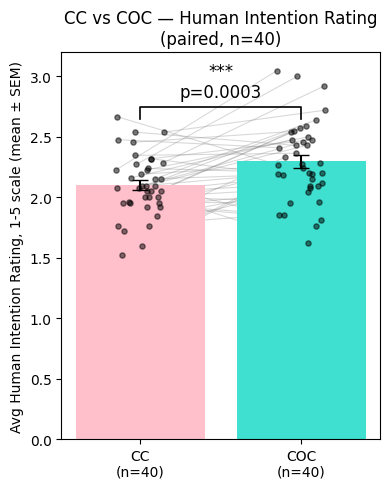

In [8]:
### Analysis 1C -- Human intention rating: CC vs COC (paired t-test)

# Load and average human ratings
human_ratings_raw = pd.read_csv(Path().resolve() / "../../human_data/franken/exp2_moralperm-intent-rating/data_long_format.csv")
avg_int = (human_ratings_raw
           .groupby(["scenario_id", "causal_structure", "evitability", "action"])["intention_rating"]
           .mean().reset_index()
           .rename(columns={"intention_rating": "avg_intention_rating"}))

# Split CC (causal_structure=0) and COC (causal_structure=1), then merge to form pairs -- each pair is the same scenario_id x evitability x action, but with the CC vs COC version of that scenario
cc_avg  = avg_int[avg_int["causal_structure"] == 0][["scenario_id","evitability","action","avg_intention_rating"]].rename(columns={"avg_intention_rating": "cc_rating"})
coc_avg = avg_int[avg_int["causal_structure"] == 1][["scenario_id","evitability","action","avg_intention_rating"]].rename(columns={"avg_intention_rating": "coc_rating"})
paired  = cc_avg.merge(coc_avg, on=["scenario_id","evitability","action"]).reset_index(drop=True)
paired["diff"] = paired["cc_rating"] - paired["coc_rating"]

t_stat, p_val = ttest_rel(paired["cc_rating"], paired["coc_rating"])
cohens_d = paired["diff"].mean() / paired["diff"].std(ddof=1)

print(f"n pairs = {len(paired)}")
print(f"CC  mean intention rating: {paired['cc_rating'].mean():.3f}  (SD={paired['cc_rating'].std():.3f})")
print(f"COC mean intention rating: {paired['coc_rating'].mean():.3f}  (SD={paired['coc_rating'].std():.3f})")
print(f"Mean difference CC - COC : {paired['diff'].mean():.3f}  (SD={paired['diff'].std():.3f})")
print(f"Paired t-test: t={t_stat:.3f}, p={p_val:.4f}  {sig_stars(p_val)}")
print(f"Paired Cohen's d = {cohens_d:.3f}")

fig, ax = plt.subplots(figsize=(4, 5))
means, sems, n = paired_bar_dot_sem(ax, paired["cc_rating"], paired["coc_rating"], "CC", "COC", colors=["pink", "turquoise"])
y_top = max(m + s for m, s in zip(means, sems)) + 0.3
ax.plot([0, 0, 1, 1], [y_top, y_top + 0.1, y_top + 0.1, y_top], lw=1.2, c="black")
ax.text(0.5, y_top + 0.15, f"{sig_stars(p_val)}\np={p_val:.4f}", ha="center", va="bottom", fontsize=12)
ax.set_ylabel("Avg Human Intention Rating, 1-5 scale (mean ± SEM)")
ax.set_title(f"CC vs COC — Human Intention Rating\n(paired, n={len(paired)})")
plt.tight_layout()
plt.show()

### **RESULT:** Hypothesis is not true; COC (side-effect harm) scenarios get a very slightly higher intentionality rating than CC -- but this could be a noise issue.

# Analysis 2 -- Do "evitable" scenarios generate more causal events than "inevitable" scenarios?
### Comparing the per-scenario proportion of "C+" events between Evitable and Inevitable counterparts of the causal conditions (also checking overall across all)
### **Commonsense hypothesis =** Evitable scenarios should have more events with more "control" over the outcome than inevitable, i.e. get more C+'s than inevitable scenarios.

### Same scenario-level, paired-by-SID improvement as Analysis 1 (paired here by SID x causal_structure x action, varying only evitability).

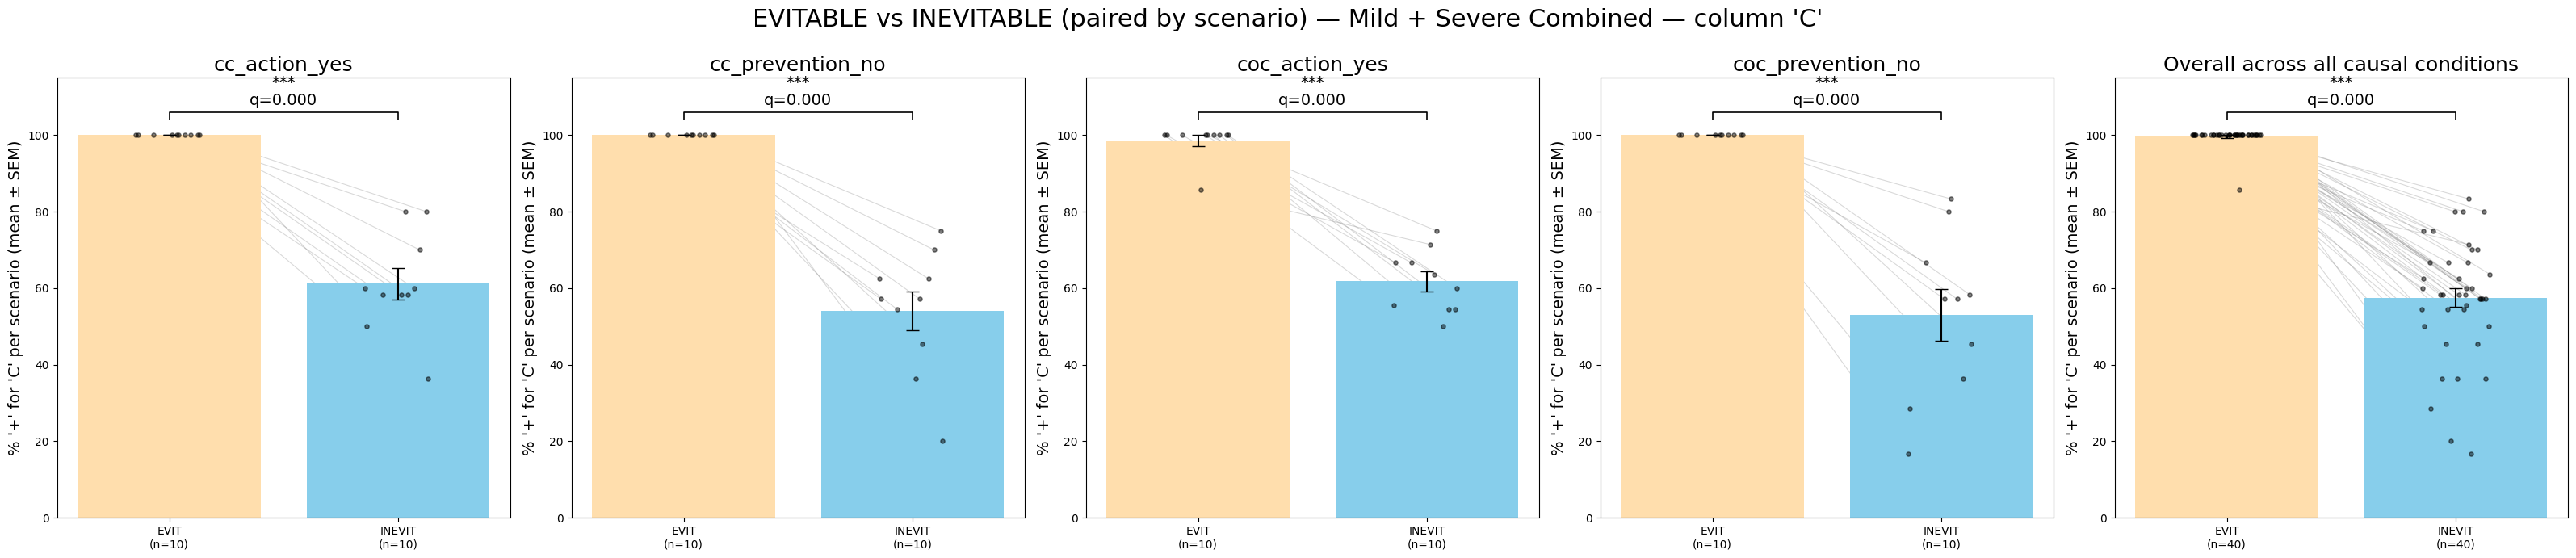

In [40]:
condition_pairs_evit_inevit = [
    ("cc_evitable_action_yes_stories",     "cc_inevitable_action_yes_stories",     "cc_action_yes"),
    ("cc_evitable_prevention_no_stories",  "cc_inevitable_prevention_no_stories",  "cc_prevention_no"),
    ("coc_evitable_action_yes_stories",    "coc_inevitable_action_yes_stories",    "coc_action_yes"),
    ("coc_evitable_prevention_no_stories", "coc_inevitable_prevention_no_stories", "coc_prevention_no"),
]

# paired_proportion_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="C",
#                             condition_pairs=condition_pairs_evit_inevit, pair_labels=("EVIT", "INEV"),
#                             colors=["navajowhite", "skyblue"],
#                             suptitle="EVITABLE vs INEVITABLE (paired by scenario) — Mild Harm/Mild Good — column 'C'")
# paired_proportion_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="C",
#                             condition_pairs=condition_pairs_evit_inevit, pair_labels=("EVIT", "INEV"),
#                             colors=["navajowhite", "skyblue"],
#                             suptitle="EVITABLE vs INEVITABLE (paired by scenario) — Severe Harm/Very Good — column 'C'")
paired_proportion_barplots(all_FRANKEN_df, "Mild + Severe Combined", column="C",
                            condition_pairs=condition_pairs_evit_inevit, pair_labels=("EVIT", "INEVIT"),
                            colors=["navajowhite", "skyblue"],
                            suptitle="EVITABLE vs INEVITABLE (paired by scenario) — Mild + Severe Combined — column 'C'")

#### **RESULT:** Hypothesis is true -- Evitable scenarios generate more C+ (causal) events compared to inevitable scenarios.

# Analysis 3 -- Do "commission" scenarios generate more intentional events than "omission" scenarios?
### Comparing the per-scenario proportion of "I+" events between action_yes (commission) and prevention_no (omission) counterparts of the causal conditions (also checking overall across all)
### **Commonsense hypothesis =** Explicitly acting towards a harm feels more intentional than letting it happen passively, so they should get more I+ events.

### Same scenario-level, paired-by-SID improvement as Analyses 1 and 2 (paired here by SID x causal_structure x evitability, varying only action).

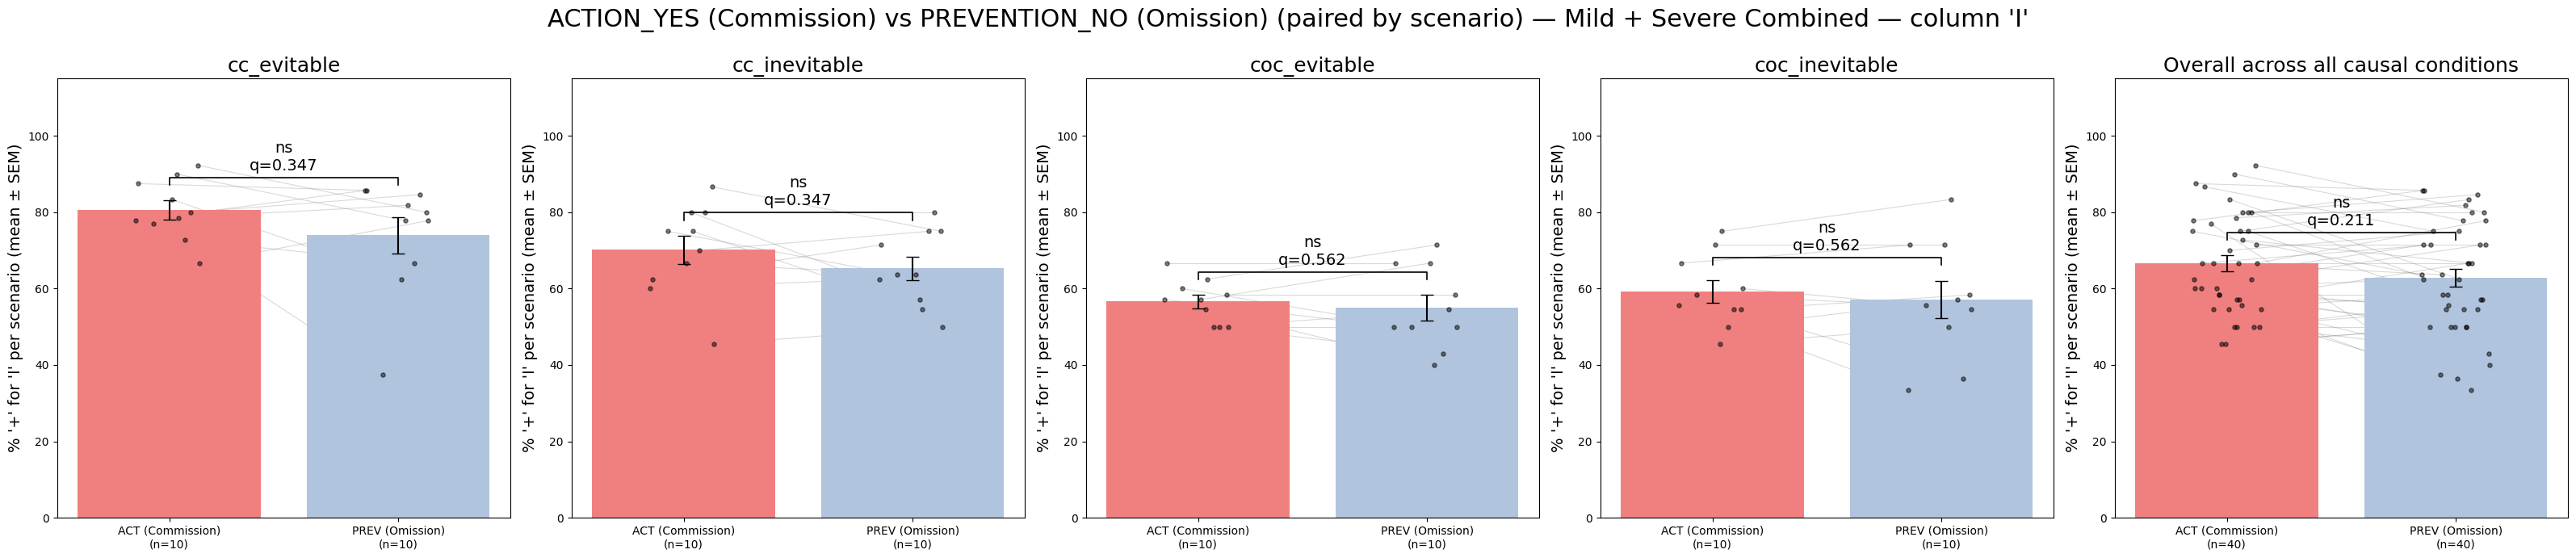

In [41]:
condition_pairs_action_prevention = [
    ("cc_evitable_action_yes_stories",    "cc_evitable_prevention_no_stories",    "cc_evitable"),
    ("cc_inevitable_action_yes_stories",  "cc_inevitable_prevention_no_stories",  "cc_inevitable"),
    ("coc_evitable_action_yes_stories",   "coc_evitable_prevention_no_stories",   "coc_evitable"),
    ("coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories", "coc_inevitable"),
]

# paired_proportion_barplots(mild_FRANKEN_df, "Mild Harm/Mild Good", column="I",
#                             condition_pairs=condition_pairs_action_prevention, pair_labels=("ACT", "PREV"),
#                             colors=["lightcoral", "lightsteelblue"],
#                             suptitle="ACTION_YES (Commission) vs PREVENTION_NO (Omission) (paired by scenario) — Mild Harm/Mild Good — column 'I'")
# paired_proportion_barplots(severe_FRANKEN_df, "Severe Harm/Very Good", column="I",
#                             condition_pairs=condition_pairs_action_prevention, pair_labels=("ACT", "PREV"),
#                             colors=["lightcoral", "lightsteelblue"],
#                             suptitle="ACTION_YES (Commission) vs PREVENTION_NO (Omission) (paired by scenario) — Severe Harm/Very Good — column 'I'")
paired_proportion_barplots(all_FRANKEN_df, "Mild + Severe Combined", column="I",
                            condition_pairs=condition_pairs_action_prevention, pair_labels=("ACT (Commission)", "PREV (Omission)"),
                            colors=["lightcoral", "lightsteelblue"],
                            suptitle="ACTION_YES (Commission) vs PREVENTION_NO (Omission) (paired by scenario) — Mild + Severe Combined — column 'I'")

### **RESULT:** Hypothesis is not true -- there is not A significant difference in proportion of I+ events generated between ACT (comission) and PREV (omission) scenarios.

# Analysis 4 -- Do "severe" scenarios get events with more extreme utility scores than "mild" scenarios?
### Comparing the utility score distributions between mild and severe counterparts of each causal condition (also checking overall)
### **Commonsense hypothesis =** The "severe_harm_very_good" utility distributions SHOULD be more negative (on the harm side) AND more positive (on the good side) overall than the "mild_harm_mild_good" utility distributions.

#### **How do we pick one utility score to represent a scenario?**
##### We need to pick the utility score of one event for a scenario -- this event should be the "primary harm" (or, for the good-magnitude test below, "primary good") event.
1. ##### **Quantitative way to do it:** look at the utility score ascribed by the annotator to all events, pick the most negative (harm) or most positive (good) score
    - ##### Each identified entity gets its own utility score, so there are multiple sub-strategies:

        - ##### **Simplest:** pick the single most extreme utility score **regardless of entity** across all events of a scenario
        - ##### **"I"-only:** pick the single most extreme utility score **assigned to "I"** across all events of a scenario, i.e., where I (agent) was most affected
        - ##### **Non-"I"-only:** pick the single most extreme utility score **not assigned to "I"** across all events of a scenario, i.e., where some patient was most affected

2. ##### **Qualitative way to do it:** look at all events, pick the most salient harm event by hand, then either pick the utility score ascribed to "I" or the worst-affected non-"I" entity.

##### **Below, only the Quantitative, "simplest" strategy is implemented** for both the harm side (most-negative utility) and the good side (most-positive utility).

##### Change the utility-picking strategies here:

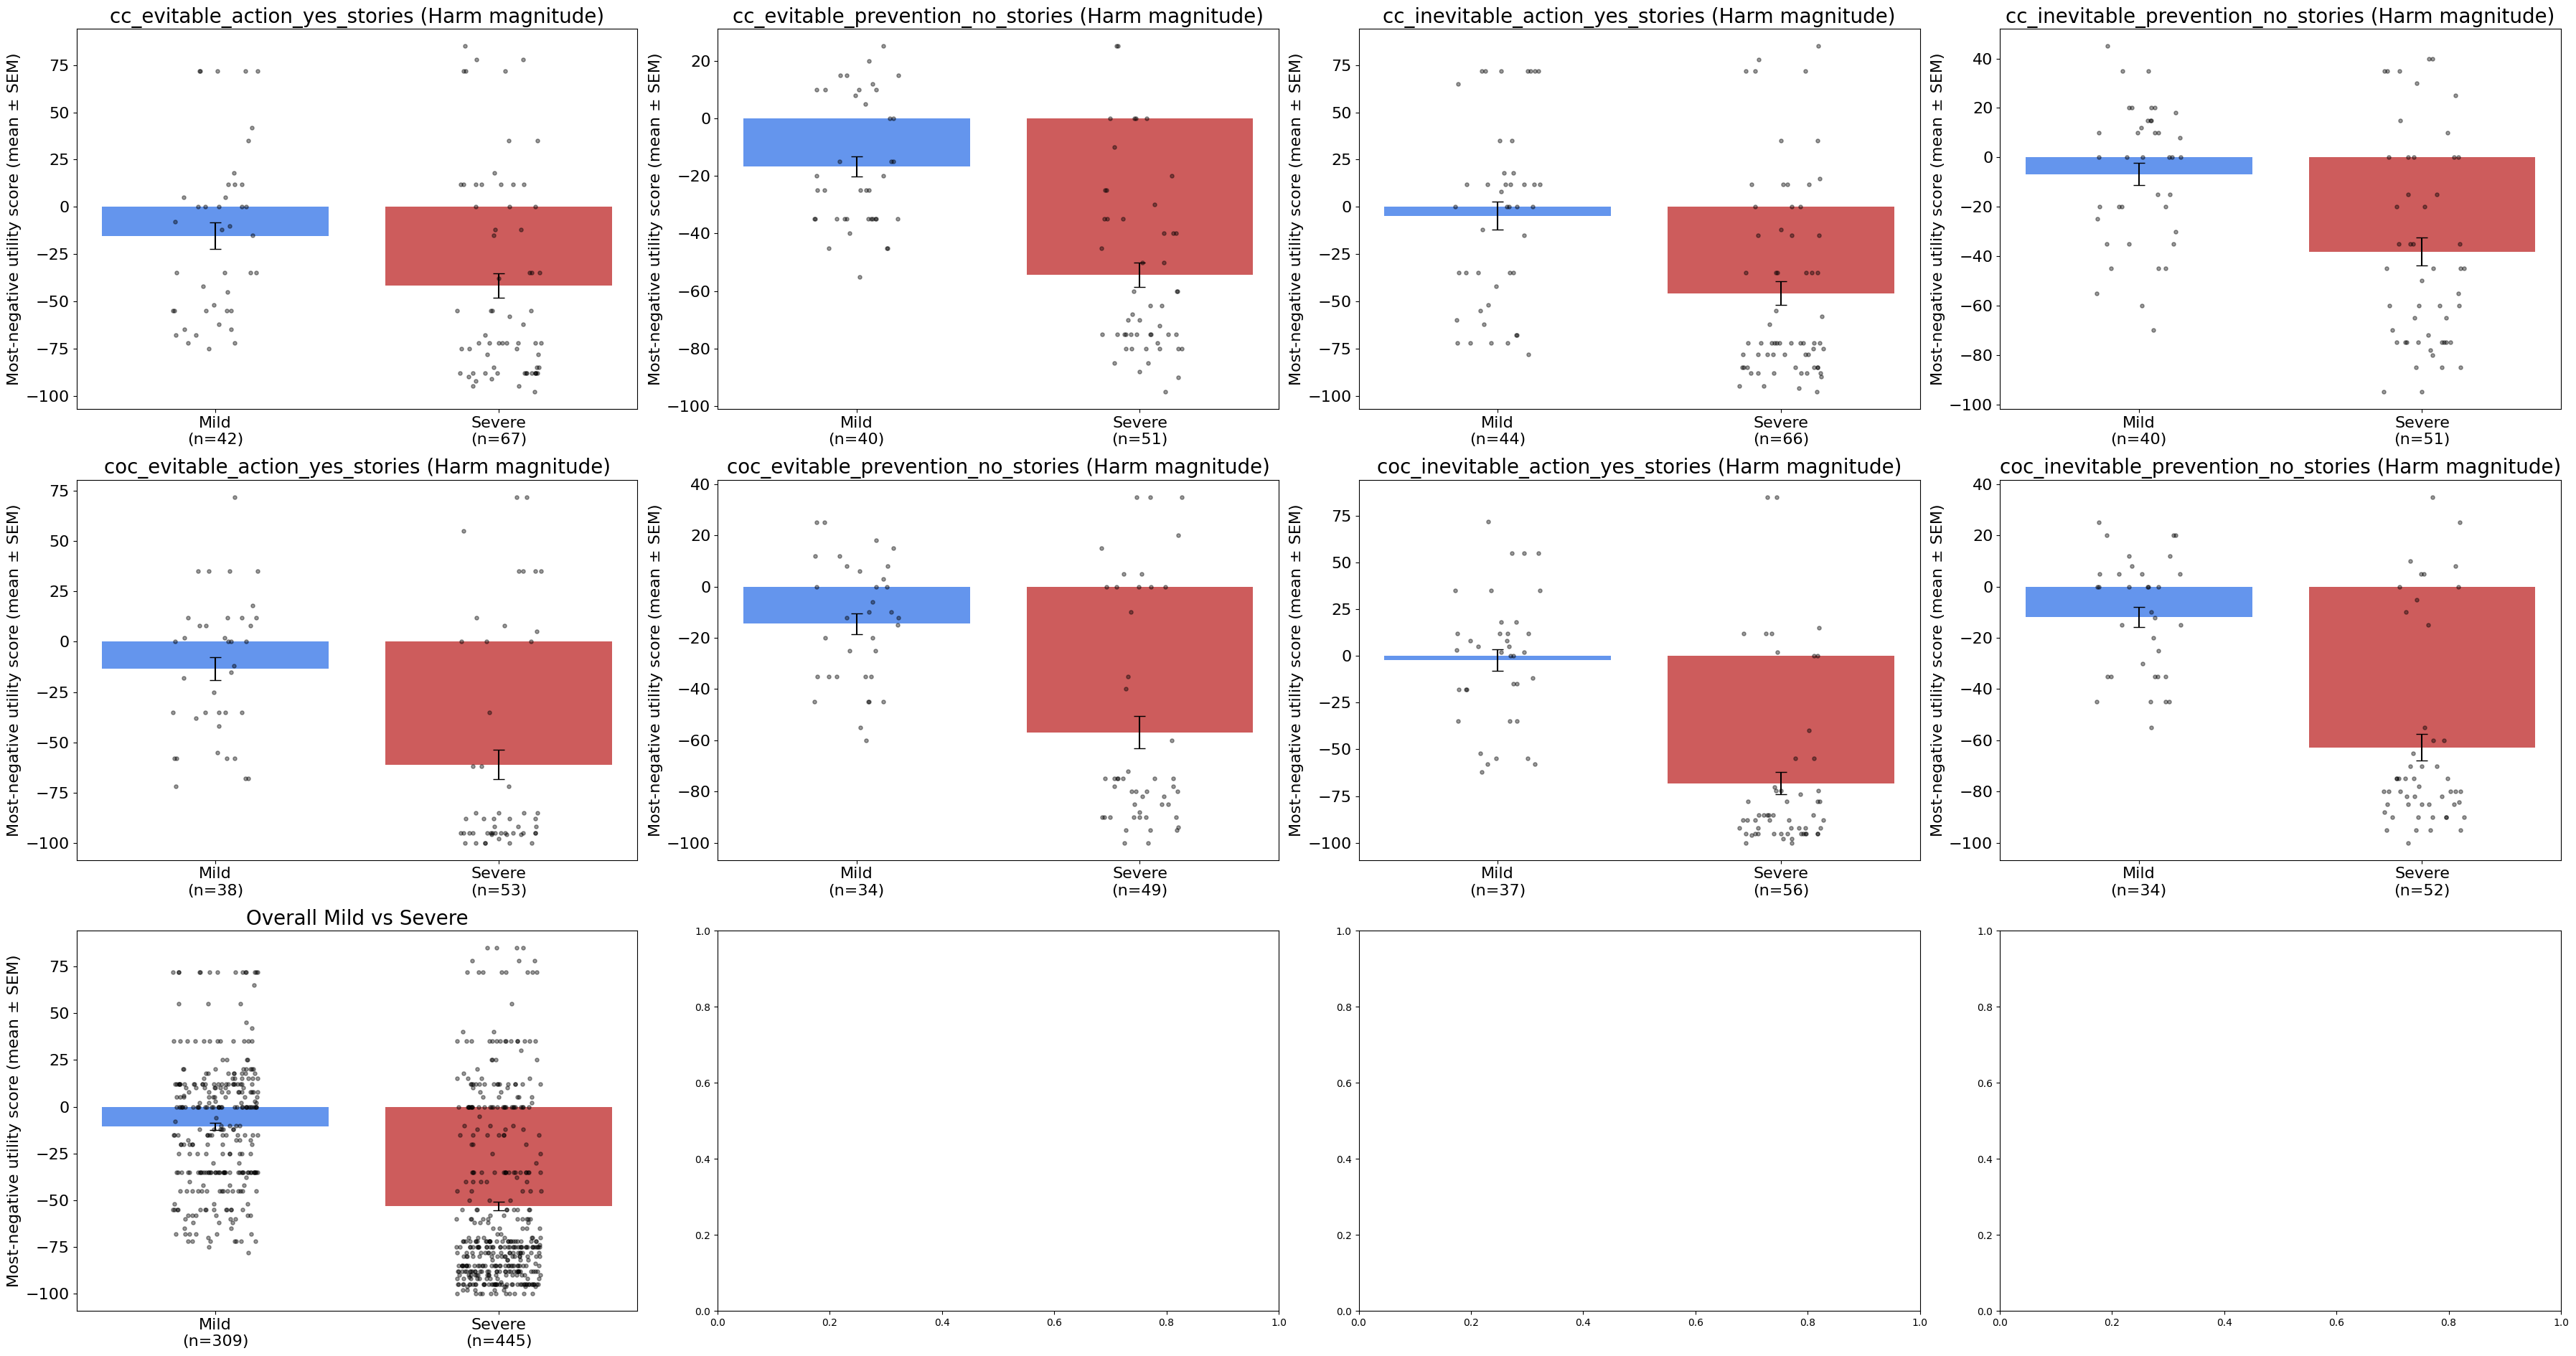

In [11]:
def extract_min_utility(utility_dict):
    """Most-negative utility score in the scenario -- represents the "primary harm" magnitude."""
    utility_dict = {k: float(v) for k, v in utility_dict.items()}
    return min(utility_dict.values())

def extract_max_utility(utility_dict):
    """Most-positive utility score in the scenario -- represents the "primary good" magnitude."""
    utility_dict = {k: float(v) for k, v in utility_dict.items()}
    return max(utility_dict.values())

# kept for compatibility with later cells (Analysis 5A/5B) that pick the primary-harm event
extract_utility_score = extract_min_utility

def create_utility_bar_dot_plots(df, title_suffix, extractor, ylabel):
    # make 3 rows of plots, 4 plots in the first two rows and 1 overall plot in the third row
    fig, axs = plt.subplots(3, 4, figsize=(36, 19))
    axs = axs.flatten()
    causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]
    for i, causal_condition in enumerate(causal_conditions):
        mild_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "mild_harm_mild_good")]["utility"].apply(extractor).dropna()
        severe_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "severe_harm_very_good")]["utility"].apply(extractor).dropna()
        bar_dot_sem(axs[i], {"Mild": mild_data, "Severe": severe_data})
        axs[i].tick_params(axis='x', labelsize=16)
        axs[i].set_title(f"{causal_condition} {title_suffix}", fontsize=20)
        axs[i].set_ylabel(ylabel, fontsize=16)
        axs[i].tick_params(axis='y', labelsize=16)
    overall_mild_data = df[df["intensity"] == "mild_harm_mild_good"]["utility"].apply(extractor).dropna()
    overall_severe_data = df[df["intensity"] == "severe_harm_very_good"]["utility"].apply(extractor).dropna()
    bar_dot_sem(axs[8], {"Mild": overall_mild_data, "Severe": overall_severe_data})
    axs[8].set_title("Overall Mild vs Severe", fontsize=20)
    axs[8].set_ylabel(ylabel, fontsize=16)
    axs[8].tick_params(axis='y', labelsize=16)
    axs[8].tick_params(axis='x', labelsize=16)

    plt.tight_layout()
    plt.show()

create_utility_bar_dot_plots(all_FRANKEN_df, "(Harm magnitude)", extract_min_utility, "Most-negative utility score (mean ± SEM)")

### **RESULT:**

- ### The utility scores look more negative-shifted in general for severe scenarios in general.

- ### This tell us that the "severe" scenarios' worst scores are more negative than "mild" scenarios' worst scores. (So "severe_harm" is indeed more severe than "mild_harm"). 

- ### Is "_very_good" indeed more good than "_mild_good" though? We don't know that part. We could know if we compared the most positive event utility scores b/w severe and mild scenarios instead (which would be the opposite of a primary harm), but it doesn't really matter as a thing to check. I suspect it is true.

### Is the severe utility distribution **statistically significantly** more negative (harm) than the mild distribution? One-sided t-tests, BH-FDR corrected across the 9 tests (8 causal conditions + overall) within each of the two utility directions:

In [12]:
def perform_t_tests(df, extractor, alternative):
    """alternative='less' tests severe < mild (harm side); alternative='greater' tests severe > mild (good side)."""
    causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]
    results = {}
    keys, p_vals = [], []
    for causal_condition in causal_conditions:
        mild_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "mild_harm_mild_good")]["utility"].apply(extractor).dropna()
        severe_data = df[(df["causal_condition"] == causal_condition) & (df["intensity"] == "severe_harm_very_good")]["utility"].apply(extractor).dropna()
        t_stat, p_value = ttest_ind(severe_data, mild_data, alternative=alternative)
        results[causal_condition] = {"t_stat": t_stat, "p_value": p_value}
        keys.append(causal_condition)
        p_vals.append(p_value)

    overall_mild_data = df[df["intensity"] == "mild_harm_mild_good"]["utility"].apply(extractor).dropna()
    overall_severe_data = df[df["intensity"] == "severe_harm_very_good"]["utility"].apply(extractor).dropna()
    t_stat, p_value = ttest_ind(overall_severe_data, overall_mild_data, alternative=alternative)
    results["overall"] = {"t_stat": t_stat, "p_value": p_value}
    keys.append("overall")
    p_vals.append(p_value)

    _, p_adj, _, _ = multipletests(p_vals, method="fdr_bh")
    for k, q in zip(keys, p_adj):
        results[k]["p_adj_fdr"] = q
    return results

print("Harm magnitude (most-negative utility): one-sided test that severe < mild, BH-FDR corrected across 9 tests:")
harm_t_test_results = perform_t_tests(all_FRANKEN_df, extract_min_utility, alternative="less")
pprint.pprint(harm_t_test_results)

# print("\nGood magnitude (most-positive utility): one-sided test that severe > mild, BH-FDR corrected across 9 tests:")
# good_t_test_results = perform_t_tests(all_FRANKEN_df, extract_max_utility, alternative="greater")
# pprint.pprint(good_t_test_results)

Harm magnitude (most-negative utility): one-sided test that severe < mild, BH-FDR corrected across 9 tests:
{'cc_evitable_action_yes_stories': {'p_adj_fdr': np.float64(0.004783778597584393),
                                    'p_value': np.float64(0.004783778597584393),
                                    't_stat': np.float64(-2.638578871880066)},
 'cc_evitable_prevention_no_stories': {'p_adj_fdr': np.float64(6.229375868484146e-09),
                                       'p_value': np.float64(2.7686114971040647e-09),
                                       't_stat': np.float64(-6.454857107887428)},
 'cc_inevitable_action_yes_stories': {'p_adj_fdr': np.float64(3.1195177566961726e-05),
                                      'p_value': np.float64(2.4262915885414675e-05),
                                      't_stat': np.float64(-4.233308022051441)},
 'cc_inevitable_prevention_no_stories': {'p_adj_fdr': np.float64(4.679294971793075e-05),
                                         'p_value': 

### Note: t-stat being negative means that severe scores are indeed more negative than mild.

### **RESULT:** The severe utility score distributions are (basically) always statistically significantly more negative than mild counterpart -- there is a consistent diference in utility score distribution between severe and mild scenarios

# Analysis 5 -- Does the annotator I+/- event label correlate to Exp2 human intentionality judgments?

## Analysis 5A -- I+/- vs Human Intentionality Rating using the QUALITATIVE, hand-picked primary harm event
### (stored in `mild_FRANKEN_primary_harm_df.csv`).

### Note: `avg_intention_rating` is a scenario-level human judgment, while the I+/- label compared against it here is for one specific extracted event (the hand-picked primary harm)

Qualitative pick DF: 80 rows | I+: 14, I-: 66

Correlation results — qualitative primary harm picks:
{'Overall': {'n_I+': 14,
             'n_scenarios': 80,
             'p_I_intention': 0.18606137384528937,
             'r_I_intention (point-biserial)': -0.1493598544460515}}


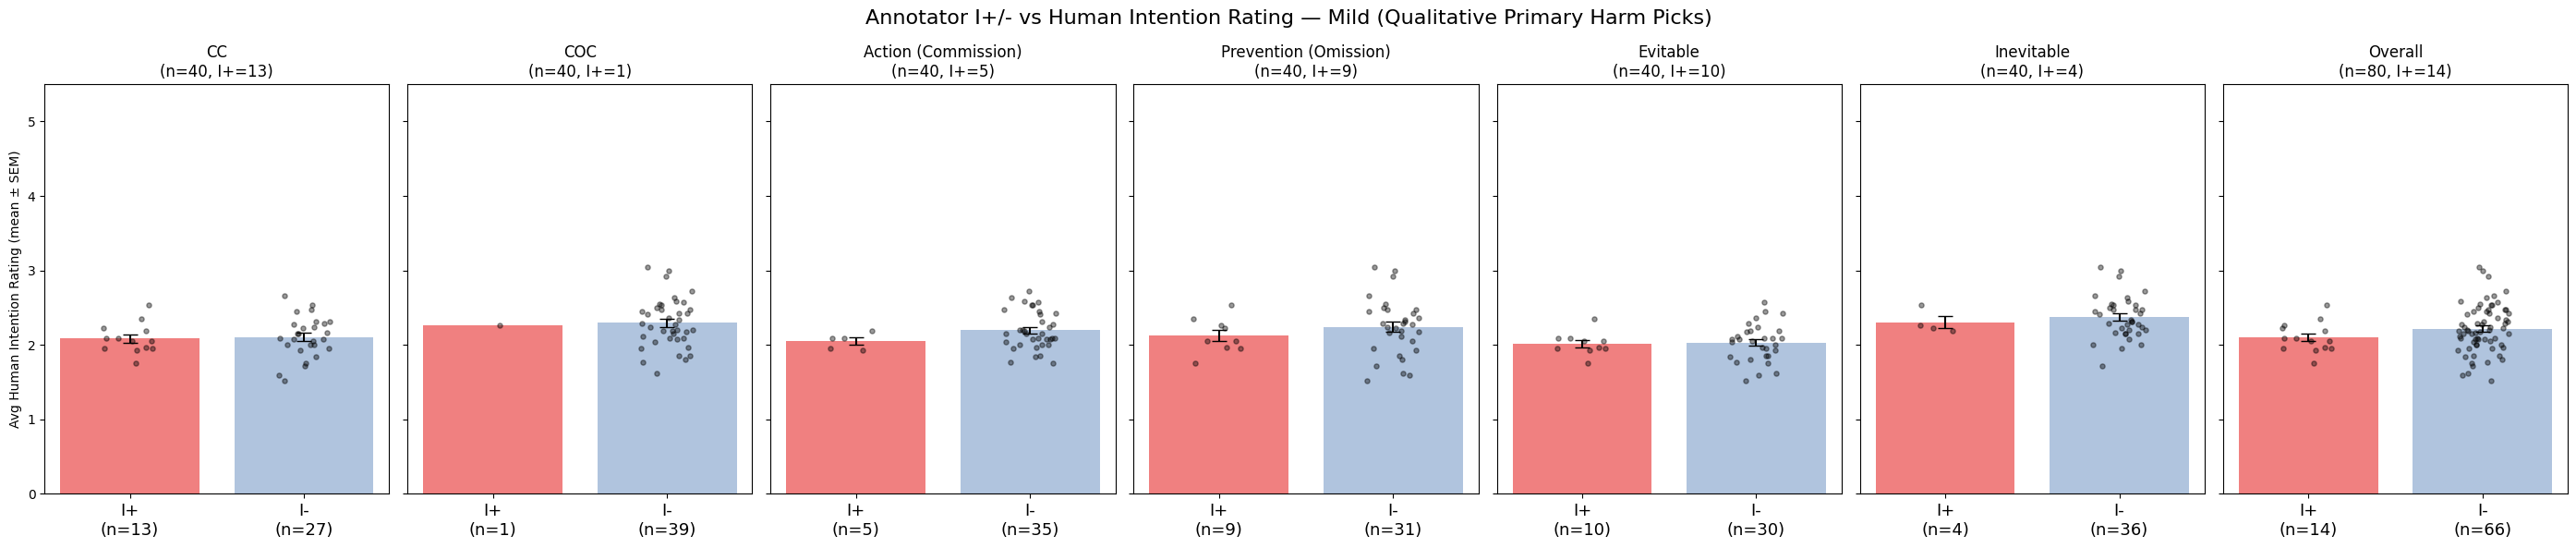

In [13]:
import ast

# mild_FRANKEN_primary_harm_df.csv already has the picked event's I, utility, and
# avg_intention_rating as scalar values -- load directly, no withhuman_df lookup needed
qualitative_scenario_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv").dropna()
qualitative_scenario_df["I_binary"] = qualitative_scenario_df["I"].map({"+": 1, "-": 0})
qualitative_scenario_df["I_label"]  = qualitative_scenario_df["I"].map({"+": "I+", "-": "I-"})
qualitative_scenario_df["utility_score"] = qualitative_scenario_df["utility"].apply(
    lambda u: extract_utility_score(ast.literal_eval(u))
)

print(f"Qualitative pick DF: {len(qualitative_scenario_df)} rows | "
      f"I+: {(qualitative_scenario_df['I'] == '+').sum()}, I-: {(qualitative_scenario_df['I'] == '-').sum()}")

# --- Correlation analysis ---
groups = {
    "CC": qualitative_scenario_df[qualitative_scenario_df["causal_condition"].str.startswith("cc")],
    "COC": qualitative_scenario_df[qualitative_scenario_df["causal_condition"].str.startswith("coc")],
    "Action (Commission)": qualitative_scenario_df[qualitative_scenario_df["causal_condition"].str.contains("action_yes")],
    "Prevention (Omission)": qualitative_scenario_df[qualitative_scenario_df["causal_condition"].str.contains("prevention_no")],
    "Evitable": qualitative_scenario_df[qualitative_scenario_df["causal_condition"].str.contains("_evitable_")],
    "Inevitable": qualitative_scenario_df[qualitative_scenario_df["causal_condition"].str.contains("_inevitable_")],
    "Overall": qualitative_scenario_df,
}

correlation_results_qualitative = {}
for group_name, group_df in {"Overall": qualitative_scenario_df}.items():
    group_df = group_df.dropna(subset=["avg_intention_rating"])
    r_pb, p_pb = pointbiserialr(group_df["I_binary"], group_df["avg_intention_rating"])
    correlation_results_qualitative[group_name] = {
        "r_I_intention (point-biserial)": float(r_pb),
        "p_I_intention": float(p_pb),
        "n_scenarios": len(group_df),
        "n_I+": int(group_df["I_binary"].sum()),
    }

print("\nCorrelation results — qualitative primary harm picks:")
pprint.pprint(correlation_results_qualitative)

# --- Visualization: bar (mean) + SEM error bars + jittered individual points ---
fig, axs = plt.subplots(1, 7, figsize=(28, 6), sharey=True)

for ax, (group_name, group_df) in zip(axs, groups.items()):
    group_df = group_df.dropna(subset=["avg_intention_rating"]).copy()
    n_iplus = int(group_df["I_binary"].sum())

    iplus_vals  = group_df[group_df["I_label"] == "I+"]["avg_intention_rating"]
    iminus_vals = group_df[group_df["I_label"] == "I-"]["avg_intention_rating"]

    bar_dot_sem(ax, {"I+": iplus_vals, "I-": iminus_vals}, colors=["lightcoral", "lightsteelblue"])

    ax.set_title(f"{group_name}\n(n={len(group_df)}, I+={n_iplus})", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Avg Human Intention Rating (mean ± SEM)" if ax is axs[0] else "")
    ax.set_ylim(0, 5.5)
    ax.tick_params(axis='x', labelsize=13)

plt.suptitle("Annotator I+/- vs Human Intention Rating — Mild (Qualitative Primary Harm Picks)", fontsize=16)
plt.tight_layout()
plt.show()

### **RESULT:** Annotator I+/- labelling does NOT split scenarios cleanly into human high/low intentionality rating -- the avg human intentionality rating between both groups (I+ scenarios and I- scenarios; based on label of *primary harm* event) is basically the same.

## Analysis 5B -- Same analysis but using the MOST-NEGATIVE UTILITY event as the chosen event per scenario (for direct comparison with Analysis 5A)

No NaN values found in I column.

Most-negative utility DF: 79 rows | I+: 23, I-: 56

Correlation results — most-negative utility event:
{'Overall': {'n_I+': 23,
             'n_scenarios': 79,
             'p_I_intention': 0.6870455032904205,
             'r_I_intention (point-biserial)': -0.046}}


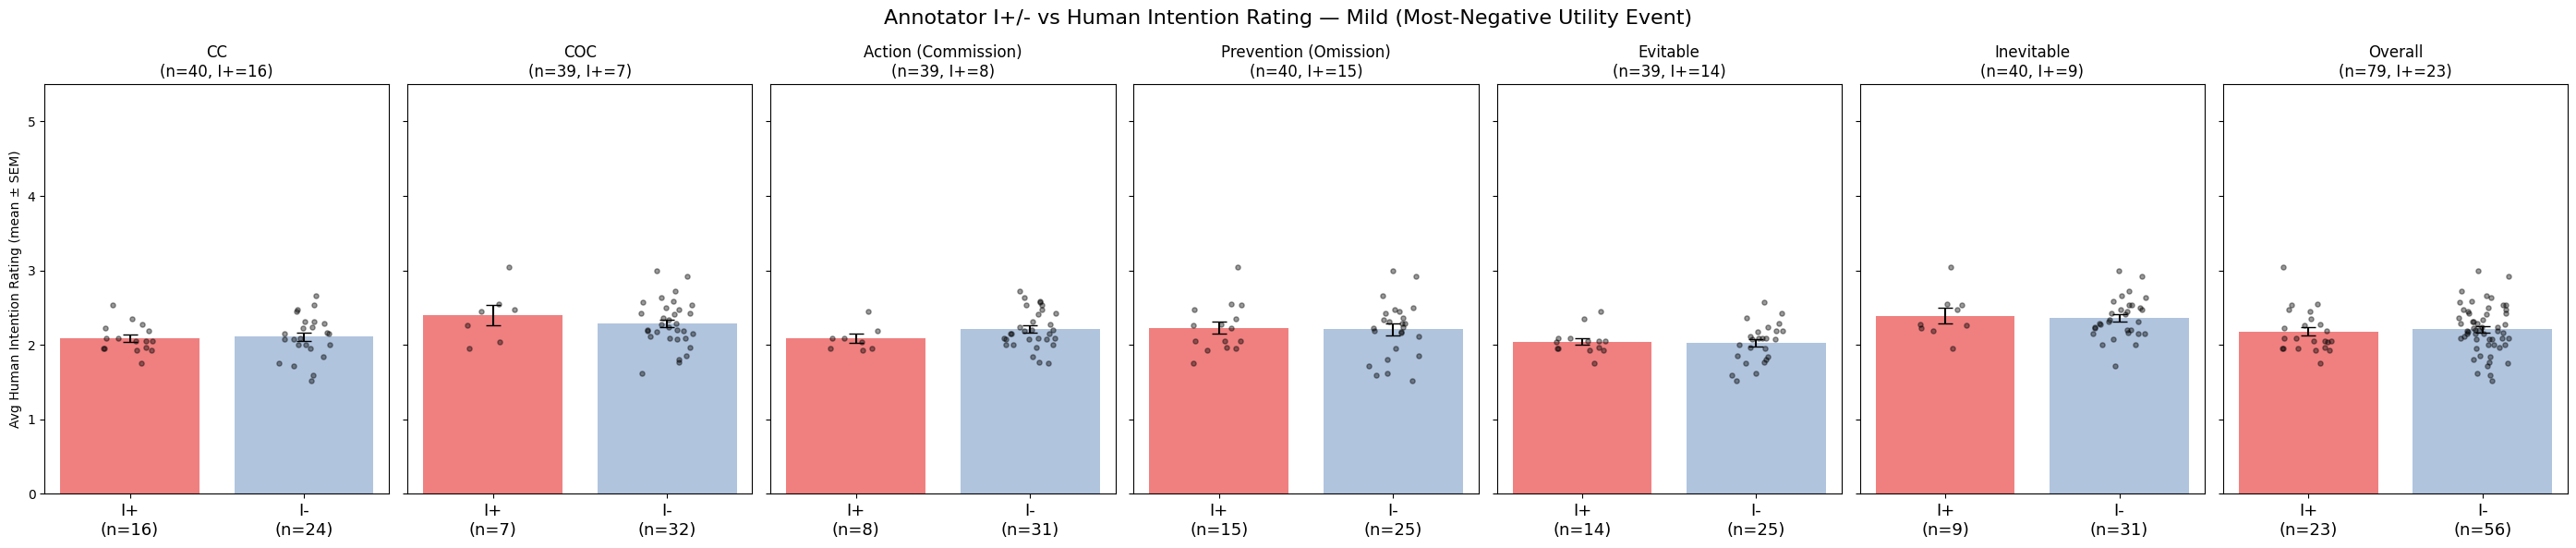

In [14]:
import ast
import re

# Load compact CSV (one row per scenario, list columns stored as strings)
compact_df = pd.read_csv("mild_FRANKEN_compact_df.csv")
compact_df = compact_df[~compact_df['I'].str.contains(r'\bnan\b', na=False)]

# utility is a list of dicts -- ast.literal_eval is fine
compact_df["utility_list"] = compact_df["utility"].apply(ast.literal_eval)
compact_df["I_list"] = compact_df["I"].apply(ast.literal_eval)

nan_rows = compact_df[compact_df.apply(lambda r: len(r["I_list"]) < len(r["utility_list"]), axis=1)]
if len(nan_rows):
    print(f"WARNING: {len(nan_rows)} scenario(s) have NaN in their I column (skipped in I_list):")
    print(nan_rows[["SID", "causal_condition", "I"]].to_string(index=False))
else:
    print("No NaN values found in I column.")

# For each scenario, pick the event with the most negative utility score
rows = []
for _, row in compact_df.iterrows():
    scores  = [extract_utility_score(u) for u in row["utility_list"]]
    min_idx = int(np.argmin(scores))
    rows.append({
        "SID": row["SID"],
        "causal_condition": row["causal_condition"],
        "I": row["I_list"][min_idx] if min_idx < len(row["I_list"]) else float("nan"),
        "utility_score": scores[min_idx],
        "avg_intention_rating": row["avg_intention_rating"],
        "avg_permissibility_rating": row["avg_permissibility_rating"],
    })

most_negative_df = pd.DataFrame(rows).dropna(subset=["avg_intention_rating"]).reset_index(drop=True)
most_negative_df["I_binary"] = most_negative_df["I"].map({"+": 1, "-": 0})
most_negative_df["I_label"]  = most_negative_df["I"].map({"+": "I+", "-": "I-"})

print(f"\nMost-negative utility DF: {len(most_negative_df)} rows | "
      f"I+: {(most_negative_df['I'] == '+').sum()}, I-: {(most_negative_df['I'] == '-').sum()}")

# --- Correlation analysis ---
groups_mn = {
    "CC": most_negative_df[most_negative_df["causal_condition"].str.startswith("cc")],
    "COC": most_negative_df[most_negative_df["causal_condition"].str.startswith("coc")],
    "Action (Commission)": most_negative_df[most_negative_df["causal_condition"].str.contains("action_yes")],
    "Prevention (Omission)": most_negative_df[most_negative_df["causal_condition"].str.contains("prevention_no")],
    "Evitable": most_negative_df[most_negative_df["causal_condition"].str.contains("_evitable_")],
    "Inevitable": most_negative_df[most_negative_df["causal_condition"].str.contains("_inevitable_")],
    "Overall": most_negative_df,
}

correlation_results_mn = {}
for group_name, group_df in {"Overall": most_negative_df}.items():
    group_df = group_df.dropna(subset=["avg_intention_rating"])
    if group_df["I_binary"].nunique() < 2:
        r_pb, p_pb = float("nan"), float("nan")
    else:
        r_pb, p_pb = pointbiserialr(group_df["I_binary"], group_df["avg_intention_rating"])

    util_df = group_df.dropna(subset=["utility_score"])
    r_pe, p_pe = pearsonr(util_df["utility_score"], util_df["avg_intention_rating"]) if len(util_df) >= 3 else (float("nan"), float("nan"))

    correlation_results_mn[group_name] = {
        "r_I_intention (point-biserial)": round(float(r_pb), 4) if not np.isnan(r_pb) else "NaN — all I-",
        "p_I_intention": float(p_pb) if not np.isnan(p_pb) else "NaN",
        "n_scenarios": len(group_df),
        "n_I+": int(group_df["I_binary"].sum()),
    }

print("\nCorrelation results — most-negative utility event:")
pprint.pprint(correlation_results_mn)

# --- Visualization: bar (mean) + SEM error bars + jittered individual points ---
fig, axs = plt.subplots(1, 7, figsize=(28, 6), sharey=True)

for ax, (group_name, group_df) in zip(axs, groups_mn.items()):
    group_df = group_df.dropna(subset=["avg_intention_rating"]).copy()
    n_iplus = int(group_df["I_binary"].sum())

    iplus_vals  = group_df[group_df["I_label"] == "I+"]["avg_intention_rating"]
    iminus_vals = group_df[group_df["I_label"] == "I-"]["avg_intention_rating"]

    bar_dot_sem(ax, {"I+": iplus_vals, "I-": iminus_vals}, colors=["lightcoral", "lightsteelblue"])

    ax.set_title(f"{group_name}\n(n={len(group_df)}, I+={n_iplus})", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Avg Human Intention Rating (mean ± SEM)" if ax is axs[0] else "")
    ax.set_ylim(0, 5.5)
    ax.tick_params(axis='x', labelsize=13)

plt.suptitle("Annotator I+/- vs Human Intention Rating — Mild (Most-Negative Utility Event)", fontsize=16)
plt.tight_layout()
plt.show()

### **RESULT:** Annotator I+/- labelling does NOT split scenarios cleanly into human high/low intentionality rating -- the avg human intentionality rating between both groups (I+ scenarios and I- scenarios; based on label of *most-negative utility* event) is basically the same.

# Analysis 6 -- Does the annotator utility/deontology score correlate to Exp1 harm/good judgments?

## Analysis 6A -- Utility vs. Exp1 harm/good judgments

### Correlating the scenario's model-assigned utility score against the corresponding human Exp1 ratings

### **Commonsense hypothesis =** A scenario a human rates as very badly harmful should also get a very negative min-utility score from the model (whether taken as the scenario's overall worst event, or specifically the picked primary-harm event), and a scenario rated as very good should get a very positive max-utility score from the model -- i.e. all three correlations should be positive.

n scenarios (most-negative event) = 80
Harm magnitude (most-negative event): avg_harm_rating vs model utility: r=0.674, p=0.0000  ***

n scenarios (primary-harm picked event) = 40
Harm magnitude (primary-harm picked event): avg_harm_rating vs model utility: r=0.199, p=0.2172  ns

n scenarios (max utility) = 80
Good magnitude: avg_good_rating vs most-positive model utility: r=0.285, p=0.0105  *


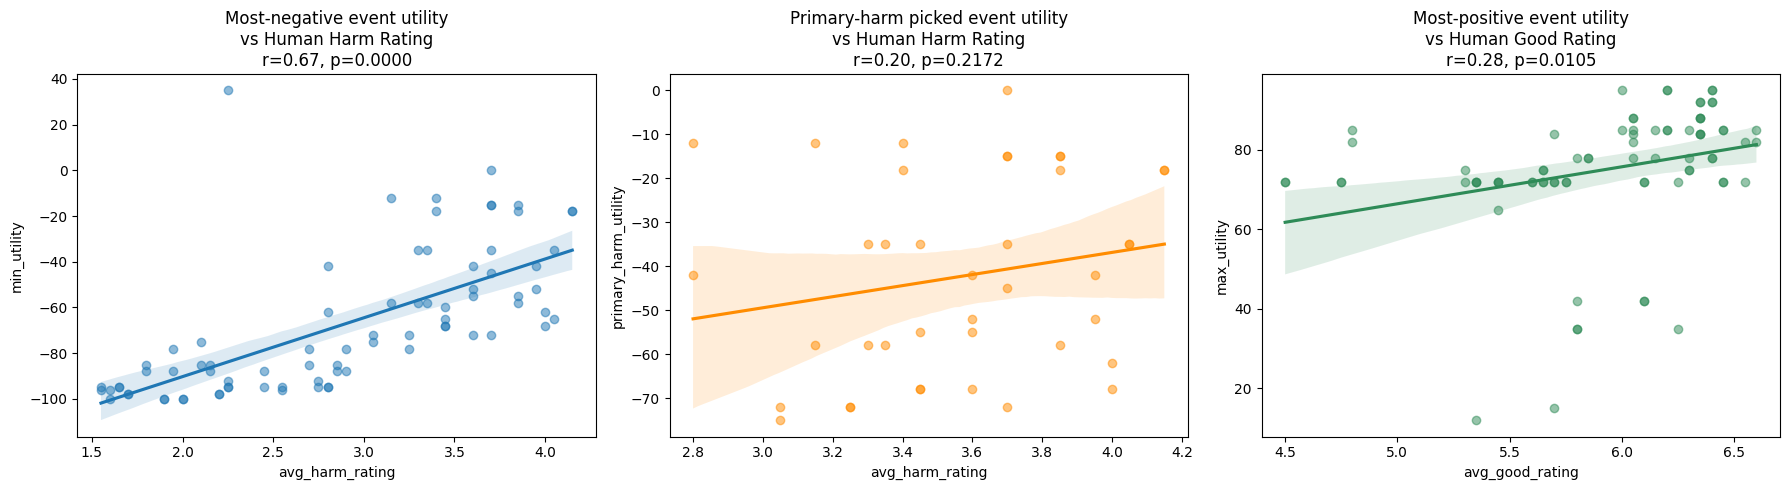

In [15]:
import ast

exp1matched_df = pd.read_csv("all_FRANKEN_exp1matched_df.csv").dropna(subset=["avg_harm_rating", "avg_good_rating"]).copy()
exp1matched_df["utility_list"] = exp1matched_df["utility"].apply(ast.literal_eval)
# utility_list is a list of one dict per event in the scenario -- take the min/max across all events' dicts
exp1matched_df["min_utility"] = exp1matched_df["utility_list"].apply(lambda events: min(extract_min_utility(u) for u in events))
exp1matched_df["max_utility"] = exp1matched_df["utility_list"].apply(lambda events: max(extract_max_utility(u) for u in events))

# Second harm-magnitude comparison: instead of the scenario's most-negative event (which could be any
# event, not necessarily the one a human would call "the harm"), use the human-picked PRIMARY HARM
# event's own utility score. Primary-harm picks only exist for mild scenarios (Exp2/pick restriction),
# so this comparison has a smaller n than the other two.
primary_harm_df_for_utility = pd.read_csv("mild_FRANKEN_primary_harm_df.csv")
primary_harm_df_for_utility = primary_harm_df_for_utility[primary_harm_df_for_utility["causal_condition"].str.contains("_action_yes_")].copy()
primary_harm_df_for_utility["primary_harm_utility"] = primary_harm_df_for_utility["utility"].apply(lambda u: extract_min_utility(ast.literal_eval(u)))

mild_harm_ratings = exp1matched_df[exp1matched_df["intensity"] == "mild_harm_mild_good"][["SID", "causal_condition", "avg_harm_rating"]]
primary_harm_vs_rating = primary_harm_df_for_utility.merge(mild_harm_ratings, on=["SID", "causal_condition"])

r_harm, p_harm = pearsonr(exp1matched_df["avg_harm_rating"], exp1matched_df["min_utility"])
r_harm_primary, p_harm_primary = pearsonr(primary_harm_vs_rating["avg_harm_rating"], primary_harm_vs_rating["primary_harm_utility"])
r_good, p_good = pearsonr(exp1matched_df["avg_good_rating"], exp1matched_df["max_utility"])

print(f"n scenarios (most-negative event) = {len(exp1matched_df)}")
print(f"Harm magnitude (most-negative event): avg_harm_rating vs model utility: r={r_harm:.3f}, p={p_harm:.4f}  {sig_stars(p_harm)}")

print(f"\nn scenarios (primary-harm picked event) = {len(primary_harm_vs_rating)}")
print(f"Harm magnitude (primary-harm picked event): avg_harm_rating vs model utility: r={r_harm_primary:.3f}, p={p_harm_primary:.4f}  {sig_stars(p_harm_primary)}")

print(f"\nn scenarios (max utility) = {len(exp1matched_df)}")
print(f"Good magnitude: avg_good_rating vs most-positive model utility: r={r_good:.3f}, p={p_good:.4f}  {sig_stars(p_good)}")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.regplot(data=exp1matched_df, x="avg_harm_rating", y="min_utility", ax=axs[0], scatter_kws={"alpha": 0.5})
axs[0].set_title(f"Most-negative event utility\nvs Human Harm Rating\nr={r_harm:.2f}, p={p_harm:.4f}")
sns.regplot(data=primary_harm_vs_rating, x="avg_harm_rating", y="primary_harm_utility", ax=axs[1], scatter_kws={"alpha": 0.5}, color="darkorange")
axs[1].set_title(f"Primary-harm picked event utility\nvs Human Harm Rating\nr={r_harm_primary:.2f}, p={p_harm_primary:.4f}")
sns.regplot(data=exp1matched_df, x="avg_good_rating", y="max_utility", ax=axs[2], scatter_kws={"alpha": 0.5}, color="seagreen")
axs[2].set_title(f"Most-positive event utility\nvs Human Good Rating\nr={r_good:.2f}, p={p_good:.4f}")
plt.tight_layout()
plt.show()

### **RESULT:** Hypothesis is true -- as the harm/good human rating becomes 'less-bad' (i.e. rising in both cases), the utility of the most-negative/most-positive event also goes up -- so annotator utility assignments are consistent with human ratings of goodness (if we use the max/min utility events)

### When we switch to comparing the human rating of 'harm' cases using the utility of the primary harm event (rathr than the max/min utility event), the correlation becomes much weaker (and non-significant).

# Analysis 6B -- Deontic rating vs Exp1 harm/good judgments

### Compares against **Exp1** (outcome ratings: harm/good, n=80, `all_FRANKEN_exp1matched_df.csv`)
### **Commonsense hypothesis =** Deontic rating should correlate to Exp 1 ratings

n scenarios (Exp1 panels, top row) = 80
[Exp1] deontic vs avg_harm_rating:  r=0.415, p=0.0001  ***
[Exp1] deontic vs avg_good_rating:  r=-0.058, p=0.6104  ns

n scenarios (Exp2 panels, bottom row) = 80  (40 action_yes + 40 prevention_no)
[Exp2] deontic vs avg_permissibility_rating: pooled r=-0.241, p=0.0310 *  |  action_yes r=0.032, p=0.8462 ns  |  prevention_no r=-0.254, p=0.1133 ns
[Exp2] deontic vs avg_intention_rating:      pooled r=-0.013, p=0.9086 ns  |  action_yes r=-0.012, p=0.9406 ns  |  prevention_no r=0.147, p=0.3651 ns


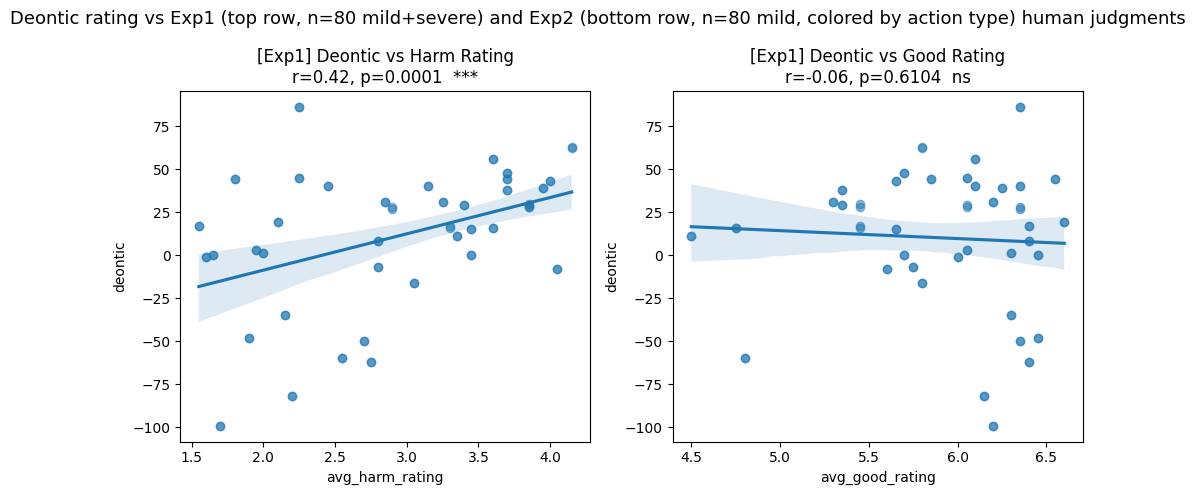

In [ ]:
exp1matched_df = pd.read_csv("all_FRANKEN_exp1matched_df.csv").dropna(subset=["avg_harm_rating", "avg_good_rating"]).copy()

# For the Exp2 (permissibility/intention) panels, use mild_FRANKEN_compact_df.csv instead of the
# exp1+exp2-matched file -- it has all 80 mild scenarios with Exp2 ratings (both action_yes and
# prevention_no causal conditions), not just the 40 that also happen to have Exp1 ratings.
# CAVEAT: deontic is almost bimodal by action type (action_yes rows average +25.8, prevention_no
# rows average -27.4, barely overlapping) while avg_permissibility_rating/avg_intention_rating do
# NOT split that way -- pooling both action types into one correlation is misleading (a pooled
# permissibility r can come out "significant" purely from the between-group gap even when neither
# action_yes nor prevention_no shows a real within-group relationship). So we color by action_type
# and report both the pooled r and the two within-group r's, rather than trusting the pooled number alone.
exp2_full_df = pd.read_csv("mild_FRANKEN_compact_df.csv").copy()
exp2_full_df["action_type"] = exp2_full_df["causal_condition"].apply(lambda c: "action_yes" if "action_yes" in c else "prevention_no")

r_deontic_harm, p_deontic_harm = pearsonr(exp1matched_df["deontic"], exp1matched_df["avg_harm_rating"])
r_deontic_good, p_deontic_good = pearsonr(exp1matched_df["deontic"], exp1matched_df["avg_good_rating"])

def pooled_and_grouped_r(df, y_col):
    r_all, p_all = pearsonr(df["deontic"], df[y_col])
    r_ay, p_ay = pearsonr(df.loc[df["action_type"] == "action_yes", "deontic"], df.loc[df["action_type"] == "action_yes", y_col])
    r_pn, p_pn = pearsonr(df.loc[df["action_type"] == "prevention_no", "deontic"], df.loc[df["action_type"] == "prevention_no", y_col])
    return (r_all, p_all), (r_ay, p_ay), (r_pn, p_pn)

(r_perm_all, p_perm_all), (r_perm_ay, p_perm_ay), (r_perm_pn, p_perm_pn) = pooled_and_grouped_r(exp2_full_df, "avg_permissibility_rating")
(r_int_all, p_int_all), (r_int_ay, p_int_ay), (r_int_pn, p_int_pn) = pooled_and_grouped_r(exp2_full_df, "avg_intention_rating")

print(f"n scenarios (Exp1 panels, top row) = {len(exp1matched_df)}")
print(f"[Exp1] deontic vs avg_harm_rating:  r={r_deontic_harm:.3f}, p={p_deontic_harm:.4f}  {sig_stars(p_deontic_harm)}")
print(f"[Exp1] deontic vs avg_good_rating:  r={r_deontic_good:.3f}, p={p_deontic_good:.4f}  {sig_stars(p_deontic_good)}")

print(f"\nn scenarios (Exp2 panels, bottom row) = {len(exp2_full_df)}  (40 action_yes + 40 prevention_no)")
print(f"[Exp2] deontic vs avg_permissibility_rating: pooled r={r_perm_all:.3f}, p={p_perm_all:.4f} {sig_stars(p_perm_all)}"
      f"  |  action_yes r={r_perm_ay:.3f}, p={p_perm_ay:.4f} {sig_stars(p_perm_ay)}"
      f"  |  prevention_no r={r_perm_pn:.3f}, p={p_perm_pn:.4f} {sig_stars(p_perm_pn)}")
print(f"[Exp2] deontic vs avg_intention_rating:      pooled r={r_int_all:.3f}, p={p_int_all:.4f} {sig_stars(p_int_all)}"
      f"  |  action_yes r={r_int_ay:.3f}, p={p_int_ay:.4f} {sig_stars(p_int_ay)}"
      f"  |  prevention_no r={r_int_pn:.3f}, p={p_int_pn:.4f} {sig_stars(p_int_pn)}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
action_palette = {"action_yes": "darkorange", "prevention_no": "steelblue"}

sns.regplot(data=exp1matched_df, x="avg_harm_rating", y="deontic", ax=axs[0], scatter_kws={"alpha": 0.5})
axs[0].set_title(f"[Exp1] Deontic vs Harm Rating\nr={r_deontic_harm:.2f}, p={p_deontic_harm:.4f}  {sig_stars(p_deontic_harm)}")

sns.regplot(data=exp1matched_df, x="avg_good_rating", y="deontic", ax=axs[1], scatter_kws={"alpha": 0.5})
axs[1].set_title(f"[Exp1] Deontic vs Good Rating\nr={r_deontic_good:.2f}, p={p_deontic_good:.4f}  {sig_stars(p_deontic_good)}")

plt.suptitle("Deontic rating vs Exp1 (top row, n=80 mild+severe) and Exp2 (bottom row, n=80 mild, colored by action type) human judgments", fontsize=13)
plt.tight_layout()
plt.show()

### **RESULT:** Hypothesis is partly true -- true for all the Exp1 judgments where hummans were shown the background sentence and a harmful target sentence, but flase for when the target sentence was the good outcome... not sure what to make of that...

# Analysis 7 -- Does Exp2 permissibility rating correlate to Exp1 harm and good magnitude?
### Regressing Exp2's `avg_permissibility_rating` on Exp1's `avg_harm_rating` and `avg_good_rating` (n=40 scenarios with both ratings: mild, action_yes causal conditions only).
### **Commonsense hypothesis =** A worse harm should make the action less permissible, and a bigger benefit should make it more permissible -- i.e. `avg_permissibility_rating` should rise with `avg_harm_rating` (since higher = a less-bad harm on this scale) and rise with `avg_good_rating`.


Bivariate: permissibility vs avg_harm_rating: r=-0.208, p=0.1989  ns
Bivariate: permissibility vs avg_good_rating:  r=0.284, p=0.0754  ns


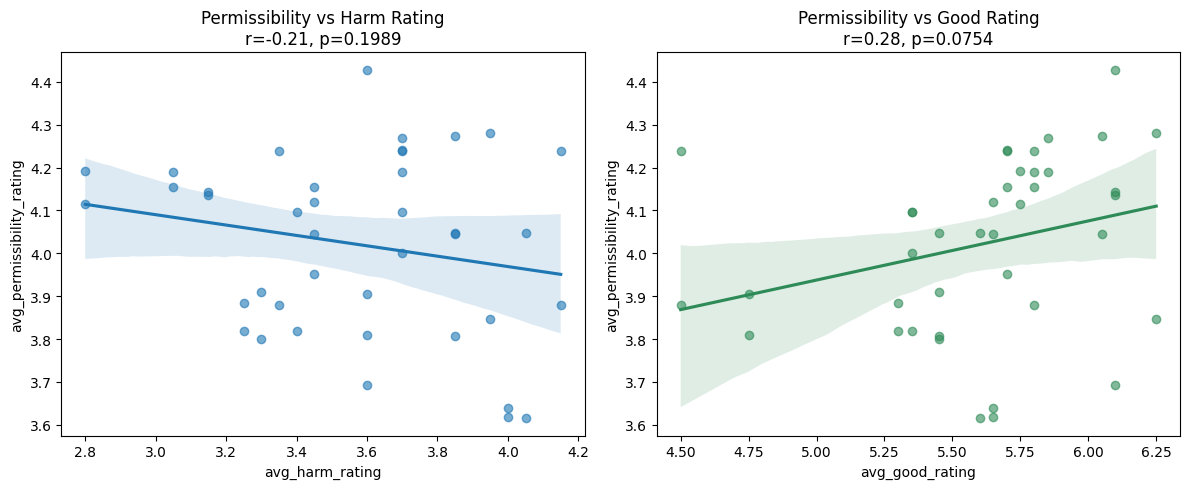

In [17]:
import statsmodels.formula.api as smf

exp1exp2_df = pd.read_csv("all_FRANKEN_exp1exp2matched_df.csv")

model = smf.ols("avg_permissibility_rating ~ avg_harm_rating + avg_good_rating", data=exp1exp2_df).fit()
# print(model.summary())

r_harm, p_harm = pearsonr(exp1exp2_df["avg_harm_rating"], exp1exp2_df["avg_permissibility_rating"])
r_good, p_good = pearsonr(exp1exp2_df["avg_good_rating"], exp1exp2_df["avg_permissibility_rating"])
print(f"\nBivariate: permissibility vs avg_harm_rating: r={r_harm:.3f}, p={p_harm:.4f}  {sig_stars(p_harm)}")
print(f"Bivariate: permissibility vs avg_good_rating:  r={r_good:.3f}, p={p_good:.4f}  {sig_stars(p_good)}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=exp1exp2_df, x="avg_harm_rating", y="avg_permissibility_rating", ax=axs[0], scatter_kws={"alpha": 0.6})
axs[0].set_title(f"Permissibility vs Harm Rating\nr={r_harm:.2f}, p={p_harm:.4f}")
sns.regplot(data=exp1exp2_df, x="avg_good_rating", y="avg_permissibility_rating", ax=axs[1], scatter_kws={"alpha": 0.6}, color="seagreen")
axs[1].set_title(f"Permissibility vs Good Rating\nr={r_good:.2f}, p={p_good:.4f}")
plt.tight_layout()
plt.show()

### **RESULT:** Hypothesis is not true -- there is no significant correlation between Exp2 permissibility rating and Exp 1 goodness ratings.

#### META-NOTE: I am currently re-running Franken through the annotator using 1) the latest state of the annotator as well as 2) using the entire set of scenarios. 

#### The current set of scenarios used above are 80 total for severe (10 in each causal condition) and 80 total for mild (10 in each causal condition).

#### The FULL set is actually 80 total for severe and 400 total for mild (50 in each causal condition). That should give us more statistical power; all that is needed is to drop in the new results, and the dataframe-making/analysis notebooks work the same. Will need to re-do primary harm event picking though...